TASK1 - Data Loading & Exploratory Analysis 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [7]:
#Target Value
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [8]:
#Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
#Summary Stats
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


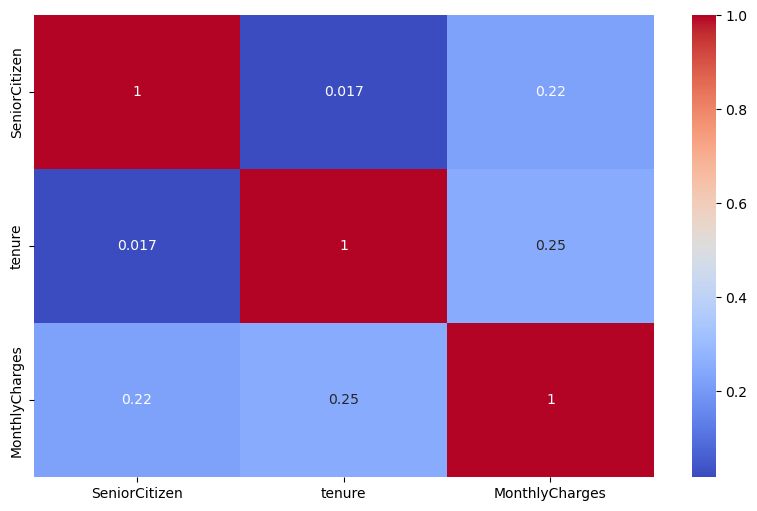

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

TASK 2 — Data Preprocessing & Feature Engineering 

In [11]:
# Convert TotalCharges to numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

# Filling with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Sumedh\AppData\Local\Temp\ipykernel_22292\3467983384.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [12]:
#Encoding
#Label Encoding is used because dataset is small and tree models handle it well
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [13]:
#Feature Engineering
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & 
                            (df['TechSupport'] == 0)).astype(int)

In [14]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges','ChargesPerMonth']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [15]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


TASK 3 — Model Training & Comparison 

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [17]:
lr = LogisticRegression()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GradientBoostingClassifier()

In [18]:
models = {'LR': lr, 'RF': rf, 'GB': gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


LR
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC: 0.8356583740215454

RF
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC-AUC: 0.8269226794802244

GB
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weight

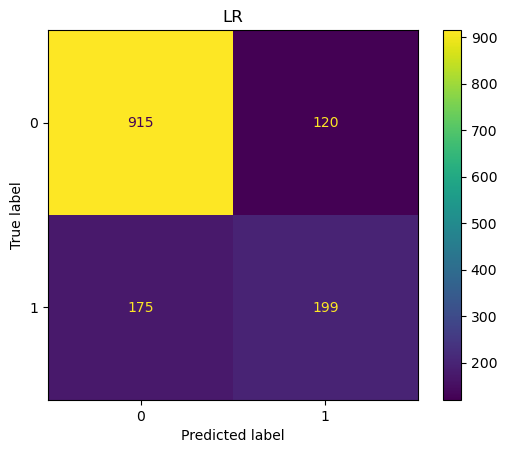

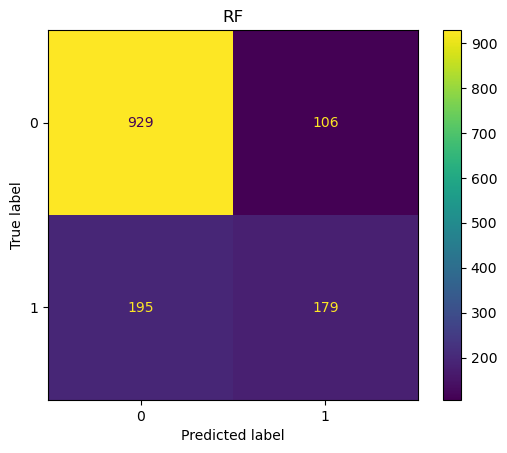

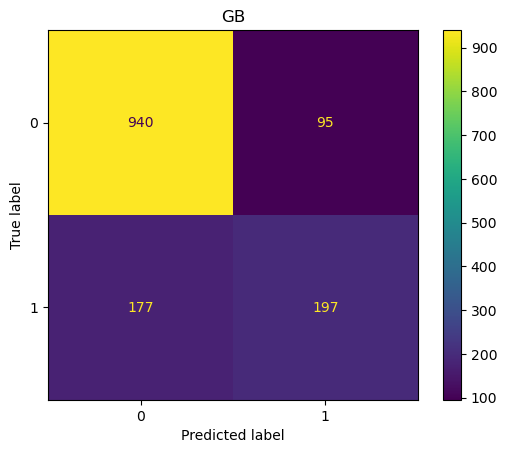

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(name)
    plt.show()

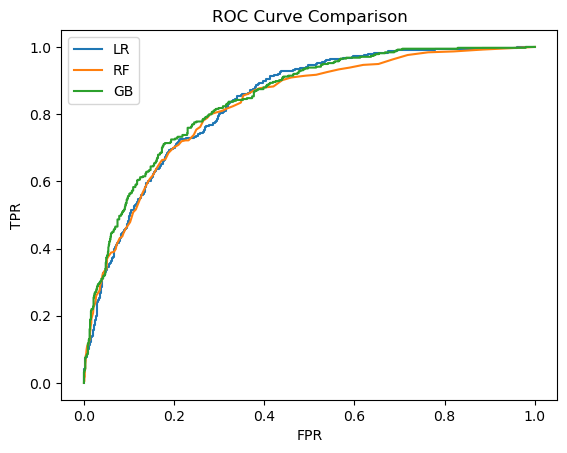

<Figure size 640x480 with 0 Axes>

In [20]:
from sklearn.metrics import roc_curve

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.show()
plt.savefig("model_comparison.png")

TASK 4 — Customer Risk Segmentation

In [21]:
best_model = rf
probs = best_model.predict_proba(X_test)[:,1]

risk = []

for p in probs:
    if p >= 0.7:
        risk.append("High")
    elif p >= 0.4:
        risk.append("Medium")
    else:
        risk.append("Low")

X_test_copy = X_test.copy()
X_test_copy['Risk'] = risk
X_test_copy['Churn'] = y_test.values

In [22]:
#Tier Analysis
X_test_copy.groupby('Risk').agg({
    'MonthlyCharges':'mean',
    'tenure':'mean'
})

,MonthlyCharges,tenure
Risk,,
High,0.484444,-1.099252
Low,-0.188701,0.314174
Medium,0.308744,-0.653156


In [23]:
#Contract Distribution
pd.crosstab(X_test_copy['Risk'], X_test_copy['Contract'])

Contract,0,1,2
Risk,,,
High,125,0,0
Low,354,292,336
Medium,294,8,0


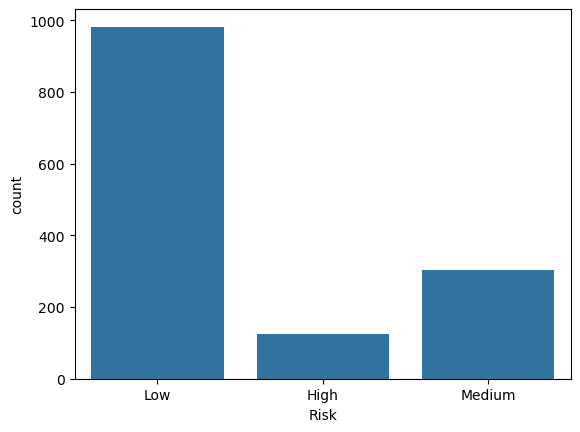

In [24]:
sns.countplot(x='Risk', data=X_test_copy)
plt.show()

TASK 5 — Visualization

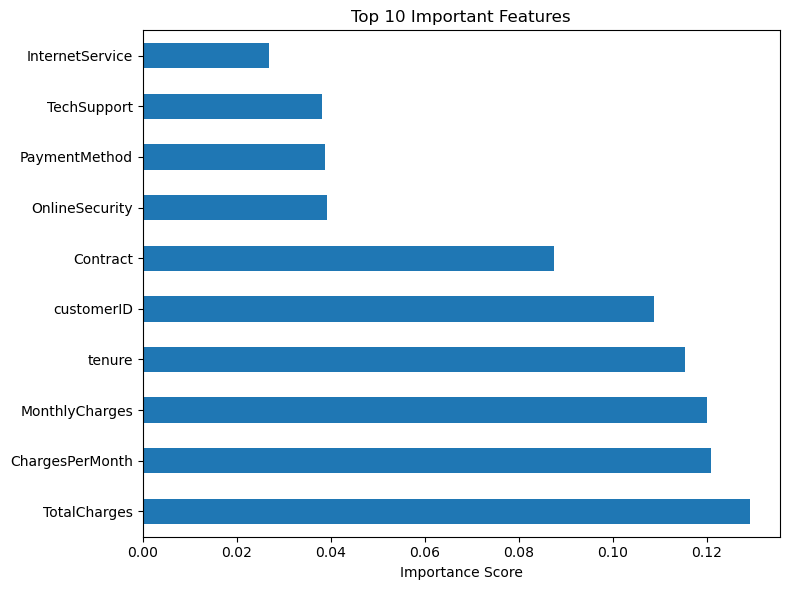

In [25]:
plt.figure(figsize=(8,6))

importances = rf.feature_importances_
feat = pd.Series(importances, index=X.columns)

feat.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig("charts/feature_importance.png")
plt.show()

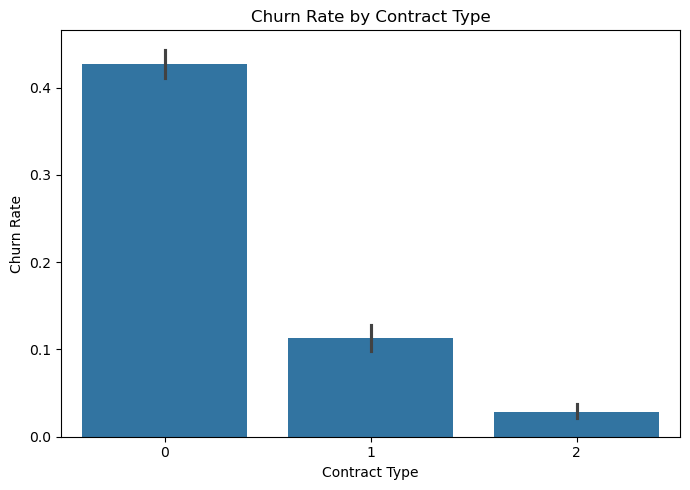

In [26]:
plt.figure(figsize=(7,5))

sns.barplot(x='Contract', y='Churn', data=df)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.tight_layout()

plt.savefig("charts/churn_by_contract.png")
plt.show()

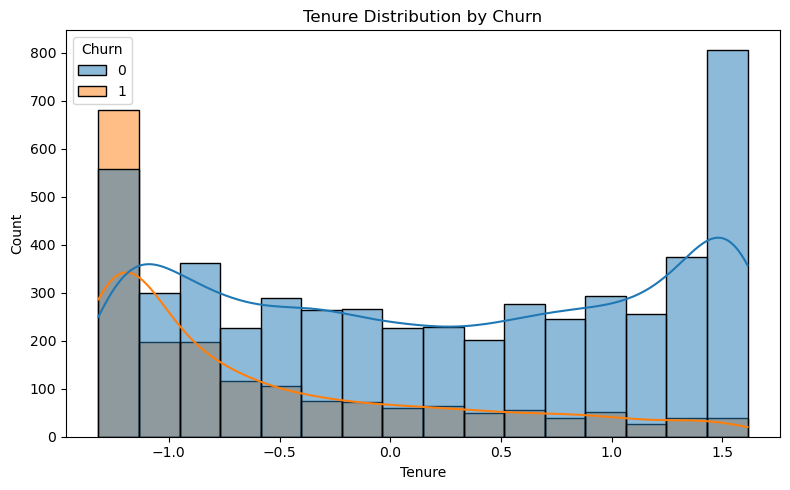

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("charts/tenure_distribution.png")
plt.show()

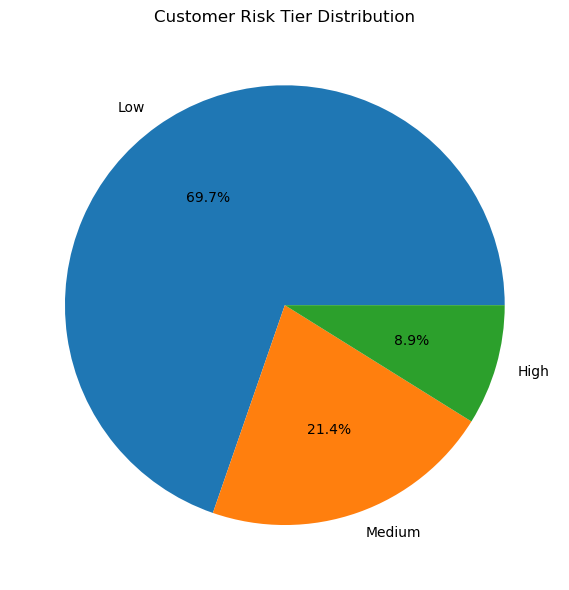

In [28]:
plt.figure(figsize=(6,6))

X_test_copy['Risk'].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title("Customer Risk Tier Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig("charts/risk_tier_pie.png")
plt.show()

 TASK 6 — Insights & Business Recommendations 
* The Random Forest model performed best because it captured non-linear relationships and feature interactions effectively.
* It achieved better overall evaluation metrics compared to Logistic Regression and Gradient Boosting.
* The top factors affecting churn were Contract Type, Tenure, and Monthly Charges.
* Customers with month-to-month contracts showed a higher probability of churn.
* Customers with lower tenure were more likely to leave the service.
* Higher monthly charges also increased the chances of customer churn.
* High-risk customers were mostly new customers with short-term contracts and higher bills.
* The company should offer loyalty discounts and incentives to convert users to long-term contracts.
* Early engagement and support programs should be introduced for new customers to improve retention.
* One limitation of the model is the lack of behavioral and complaint-related customer data.
* The model performance could be improved further using larger datasets and advanced techniques like deep learning.
